In [1]:
from sklearnex import patch_sklearn 
patch_sklearn() 

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
from time import perf_counter

# Data Fetch and Load


In [3]:
import kagglehub
import os
import shutil
root = 'zalando-research/fashionmnist'
train_name = 'fashion-mnist_train.csv'
test_name = 'fashion-mnist_test.csv'

c:\Users\alexh\Coding\MNIST\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def fetch(): 
    if os.path.exists(train_name) and os.path.exists (test_name): 
        print (f'\nAlready Fetched Dataset!!!')
        return 
    data_path = kagglehub.dataset_download(root)
    if data_path: 
        print (f'\n--------Download Successfully------')
    else: 
        print (f'\n--------Download Fail------')
    
    print (f'Delivering train set to current workspace')
    train_source = os.path.join(data_path, train_name)
    train_path = os.path.join(os.getcwd(), train_name)
    shutil.copy2 (train_source, train_path)

    print (f'Delivering test set to current workspace')
    test_source = os.path.join(data_path, test_name)
    test_path = os.path.join(os.getcwd(), test_name)
    shutil.copy2 (test_source, test_path)

fetch()



Already Fetched Dataset!!!


In [5]:
import pandas as pd 
def load(): 
    train = pd.read_csv(train_name)
    test = pd.read_csv(test_name)
    return train, test 
train, test = load()

# Data Overview


In [6]:
def overview (var, name = None): 
    print (f'\n------------Overview {name}----------')
    print (f'Type: {type(var).__name__}')
    print (f'Size: {var.size}') 
    print (f'Shape: {var.shape}') 
overview(train, 'train') 
overview(test, 'test')


------------Overview train----------
Type: DataFrame
Size: 47100000
Shape: (60000, 785)

------------Overview test----------
Type: DataFrame
Size: 7850000
Shape: (10000, 785)


In [7]:
from sklearn.model_selection import train_test_split
x_train, y_train = train.drop ('label', axis = 1).copy().to_numpy(), train['label'].copy().to_numpy()
x_test, y_test = test.drop ('label', axis = 1).copy().to_numpy(), test['label'].copy().to_numpy()
overview(x_train, 'train') 
overview(y_train, 'train') 
overview(x_test, 'test')
overview(y_test, 'test')


------------Overview train----------
Type: ndarray
Size: 47040000
Shape: (60000, 784)

------------Overview train----------
Type: ndarray
Size: 60000
Shape: (60000,)

------------Overview test----------
Type: ndarray
Size: 7840000
Shape: (10000, 784)

------------Overview test----------
Type: ndarray
Size: 10000
Shape: (10000,)


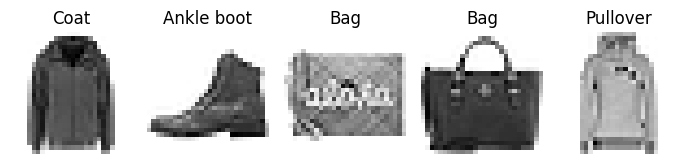

In [8]:
def map_label(index): 
    labels = [
        'T-shirt/top',
        'Trouser',
        'Pullover',
        'Dress',
        'Coat',
        'Sandal',
        'Shirt',
        'Sneaker',
        'Bag',
        'Ankle boot',
    ]
    return labels[index]

import numpy as np 
import matplotlib.pyplot as plt 
_, axes = plt.subplots (nrows = 1, ncols = 5, figsize = (7,7))
images = [None] * 5
for i in range (5): 
    index = np.random.randint (1, 60000)
    images[i] = x_train[index].reshape (28, 28) 
    axes[i].imshow (images[i], cmap = 'binary') 
    axes[i].axis ('off')
    axes[i].set_title (map_label(y_train[index]))
plt.tight_layout() 
plt.show() 

# Data Preprocessing


In [9]:
import numpy as np 
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import shift, rotate
import matplotlib.pyplot as plt

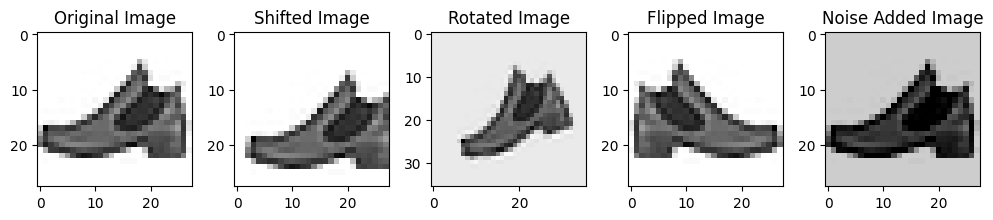

In [10]:
# Augmentation Illustration
image = x_train[1].reshape (28, 28) 
shifted_image = shift(image, [2, 2], cval = 0)
rotated_image = rotate (image, angle = 20, axes = (0,1), cval = 0)
flipped_image = np.flip (image, axis = (1))
noise_image = image + np.full(image.shape, 50)

_, axes = plt.subplots(nrows = 1, ncols = 5, figsize = (10, 10))
axes[0].imshow (image, cmap = 'binary', interpolation = 'nearest'); axes[0].set_title ('Original Image')
axes[1].imshow (shifted_image, cmap = 'binary', interpolation = 'nearest'); axes[1].set_title ('Shifted Image')
axes[2].imshow (rotated_image, cmap = 'binary', interpolation = 'nearest'); axes[2].set_title ('Rotated Image')
axes[3].imshow (flipped_image, cmap = 'binary', interpolation = 'nearest'); axes[3].set_title ('Flipped Image')
axes[4].imshow (noise_image, cmap = 'binary', interpolation = 'nearest', vmin = 0, vmax = 255); axes[4].set_title ('Noise Added Image')
plt.tight_layout()
plt.show() 

In [11]:
scaler_module = StandardScaler() 

def scaler (x: np.ndarray): 
    return scaler_module.fit_transform(x)

def data_augmentation (x, y): 
    x_expand, y_expand = [x], [y]
    x_image = x.reshape (-1, 28, 28) 

    #Shifting
    for dx, dy in ((0,2), (0,-2), (2,0), (-2, 0)): 
        shift_images = shift (x_image, [0, dx,dy], cval = 0) 
        x_expand.append (shift_images.reshape (-1, 784)) 
        y_expand.append (y) 
    print (f'-----Shift Done-------')

    #Rotating
    for angle in (-20, 20, -10, 10): 
        rotate_images = rotate (x_image, angle, axes=(1,2), reshape = False, cval = 0)
        x_expand.append(rotate_images.reshape (-1, 784))
        y_expand.append (y)
    print (f'-----Rotate Done-------')

    #Flipping
    flipped_images = np.flip (x_image, axis = (1))
    x_expand.append (flipped_images.reshape (-1, 784)) 
    y_expand.append (y)
    print (f'-----Flip Done-------')
    
    #Adding noise
    x_expand.append (x + np.full (x.shape, 50))
    y_expand.append (y)
    print (f'-----Add Noise Done-------')

    return np.concatenate(x_expand), np.concatenate(y_expand)

# Load Data


In [12]:
if not os.path.exists ('dataset_augmented_scaled.npz'): 
    print (f'dataset_augmented_scaled.npz not available on local! \nImplement Augmentation and Compress...')
    x_augmented, y_augmented = data_augmentation(x_train, y_train) 
    x_augmented_scaled = scaler (x_augmented)
    np.savez_compressed('dataset_augmented_scaled.npz', features = x_augmented_scaled, labels = y_augmented)
    print (f'-------DONE---------', end = '\n' * 2)
else: 
    print (f'Load dataset_augmented_scaled.npz directly from local...')
    dataset_augmented_scaled = np.load ('dataset_augmented_scaled.npz')
    x_augmented_scaled = dataset_augmented_scaled['features']
    y_augmented = dataset_augmented_scaled['labels']
    print (f'-------DONE---------', end = '\n' * 2)

if not os.path.exists ('dataset_scaled.npz'): 
    print (f'dataset_scaled.npz not available on local! \n Implement Augmentation and Compress...')
    x_scaled  = scaler (x_train) 
    y_scaled = y_train
    np.savez_compressed('dataset_scaled.npz', features = x_scaled, labels = y_train)
    print (f'-------DONE---------', end = '\n' * 2)

else: 
    print (f'Load dataset_scaled.npz directly from local...')
    dataset_scaled = np.load('dataset_scaled.npz')
    x_scaled = dataset_scaled['features'] 
    y_scaled = dataset_scaled['labels']
    print (f'-------DONE---------', end = '\n' * 2)

Load dataset_augmented_scaled.npz directly from local...
-------DONE---------

Load dataset_scaled.npz directly from local...
-------DONE---------



# Model Selection & Fine Tune


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import joblib
import optuna

In [14]:
x_subset, _, y_subset, _ = train_test_split ( 
    x_scaled, y_scaled, 
    train_size = 20000, 
    stratify = y_scaled, 
)

In [15]:
def cross_validation (models: list, x = x_subset, y = y_subset, cv = 3, scoring = 'accuracy'): 
    if not isinstance(models, list): 
        raise TypeError (f'Expect a list of models as input, got {type (models).__name__} instead')
    for model in models: 
        print (f'\n-----Cross Validation of {type(model).__name__}----')
        print (f'Size of each cv is: {len(x) // cv * (cv - 1)}')
        scores = cross_val_score (
            model, 
            x, y, 
            cv = cv, 
            scoring = scoring, 
            verbose = 3, 
        )
        print (scores)
        print (scores.mean())

In [16]:
cross_validation([
    RandomForestClassifier(random_state=42), 
    KNeighborsClassifier(), 
])


-----Cross Validation of RandomForestClassifier----
Size of each cv is: 13332
[CV] END ................................ score: (test=0.854) total time=   0.6s
[CV] END ................................ score: (test=0.870) total time=   0.5s
[CV] END ................................ score: (test=0.865) total time=   0.6s
[0.85375731 0.8699565  0.86483648]
0.8628500993192164

-----Cross Validation of KNeighborsClassifier----
Size of each cv is: 13332


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.9s finished


[CV] END ................................ score: (test=0.820) total time=   0.7s
[CV] END ................................ score: (test=0.837) total time=   0.7s
[CV] END ................................ score: (test=0.829) total time=   0.7s
[0.81985901 0.83725814 0.82853285]
0.8285499991427071


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.3s finished


In [17]:
def Tuning (objective, model, dump_name = ''): 
    if dump_name and not dump_name.endswith('.pkl'): 
        raise TypeError (f'Model dumping name is expected to end with ".pkl" (e.g. abc.pkl), got {dump_name} instead')
    study = optuna.create_study (direction='maximize', pruner = optuna.pruners.MedianPruner())
    optuna.logging.set_verbosity(optuna.logging.INFO)
    study.optimize(objective, n_trials = 100, n_jobs = 13)
    params = study.best_params
    model = model(**params)
    model.fit (x_augmented_scaled, y_augmented)
    if dump_name: 
        joblib.dump (model, dump_name)
    return model

In [18]:
def KNN_objective (trial): 
    n_neighbors = trial.suggest_int ('n_neighbors', 3, 20)
    weights = trial.suggest_categorical ('weights', ['uniform', 'distance'])
    p = trial.suggest_int ('p', 1, 2)

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors, 
        weights=weights, 
        p = p,
    )

    scores = cross_val_score (
        model, 
        x_subset, y_subset, 
        cv = 3, 
        scoring = 'accuracy', 
        n_jobs = -3, 
    )
    return scores.mean() 

if not os.path.exists ('KNN.pkl'): 
    knn_model = Tuning(KNN_objective, model = KNeighborsClassifier, dump_name= 'KNN.pkl') 
else: 
    knn_model = joblib.load ('KNN.pkl')

In [19]:
def random_forest_objective (trial): 
    n_estimators = trial.suggest_int ('n_estimators', 100, 200)
    max_features = trial.suggest_categorical ('max_features', ['log2', 'sqrt'])
    max_depth = trial.suggest_int ('max_depth', 10, 50)
    min_samples_leaf = trial.suggest_int ('min_samples_leaf', 1, 10)
    min_samples_split = trial.suggest_int ('min_samples_split', 2, 20)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth, 
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        n_jobs = -3,
    )
    score = cross_val_score (
        model, 
        x_subset, 
        y_subset, 
        cv = 3, 
        scoring = 'accuracy', 
        n_jobs = -3,
    )
    return score.mean()

if not os.path.exists ('Random_Forest.pkl'): 
    forest_model = Tuning(random_forest_objective, RandomForestClassifier, 'Random_Forest.pkl') 
else: 
    forest_model = joblib.load ('Random_Forest.pkl')

[I 2026-03-23 00:39:29,926] A new study created in memory with name: no-name-a89b20e3-decd-45c0-ac44-d347c09a21d0
[I 2026-03-23 00:39:50,275] Trial 11 finished with value: 0.8537500517713389 and parameters: {'n_estimators': 172, 'max_features': 'log2', 'max_depth': 24, 'min_samples_leaf': 5, 'min_samples_split': 18}. Best is trial 11 with value: 0.8537500517713389.
[I 2026-03-23 00:39:57,199] Trial 4 finished with value: 0.8505999917525875 and parameters: {'n_estimators': 125, 'max_features': 'log2', 'max_depth': 50, 'min_samples_leaf': 10, 'min_samples_split': 9}. Best is trial 11 with value: 0.8537500517713389.
[I 2026-03-23 00:39:58,902] Trial 1 finished with value: 0.8528000467663386 and parameters: {'n_estimators': 190, 'max_features': 'log2', 'max_depth': 14, 'min_samples_leaf': 5, 'min_samples_split': 2}. Best is trial 11 with value: 0.8537500517713389.
[I 2026-03-23 00:40:00,929] Trial 6 finished with value: 0.8595999317945894 and parameters: {'n_estimators': 114, 'max_features

# Validation


In [20]:
cross_validation([forest_model, knn_model])


-----Cross Validation of RandomForestClassifier----
Size of each cv is: 13332
[CV] END ................................ score: (test=0.856) total time=   1.7s
[CV] END ................................ score: (test=0.871) total time=   1.3s
[CV] END ................................ score: (test=0.863) total time=   1.1s
[0.85585721 0.87100645 0.86348635]
0.8634500018173409

-----Cross Validation of KNeighborsClassifier----
Size of each cv is: 13332


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    4.4s finished


[CV] END ................................ score: (test=0.832) total time=   2.3s
[CV] END ................................ score: (test=0.841) total time=   2.4s
[CV] END ................................ score: (test=0.837) total time=   2.4s
[0.83245838 0.84115794 0.83693369]
0.8368500041844592


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    7.3s finished


In [21]:
x_test_scaled = scaler(x_test) 
y_forest = forest_model.predict (x_test_scaled)
y_knn = knn_model.predict (x_test_scaled)

In [ ]:
# y_pred = y_forest
y_pred = y_knn

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

---------Classification Report------
              precision    recall  f1-score   support

           0       0.73      0.86      0.79      1000
           1       0.99      0.96      0.97      1000
           2       0.80      0.77      0.78      1000
           3       0.90      0.88      0.89      1000
           4       0.81      0.80      0.81      1000
           5       0.93      0.95      0.94      1000
           6       0.66      0.59      0.62      1000
           7       0.92      0.89      0.90      1000
           8       0.94      0.97      0.95      1000
           9       0.93      0.95      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



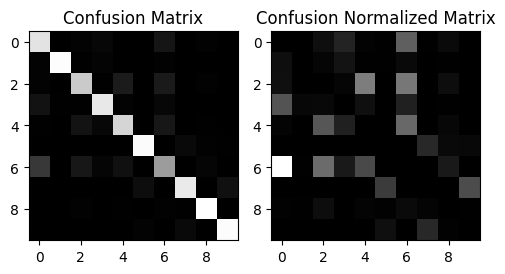

In [32]:
conf_matrix = confusion_matrix(y_test, y_pred)
row_sums = conf_matrix.sum (axis = 1, keepdims = True) 
conf_norm_matrix = conf_matrix / row_sums 
np.fill_diagonal(conf_norm_matrix, 0) 

import matplotlib.pyplot as plt 
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (5,5)) 
axes[0].imshow (conf_matrix, cmap = 'gray') 
axes[0].set_title ('Confusion Matrix') 

axes[1].imshow (conf_norm_matrix, cmap = 'gray') 
axes[1].set_title ('Confusion Normalized Matrix')

print (f'---------Classification Report------')
print (classification_report(y_test, y_pred))

plt.tight_layout()
plt.show() 

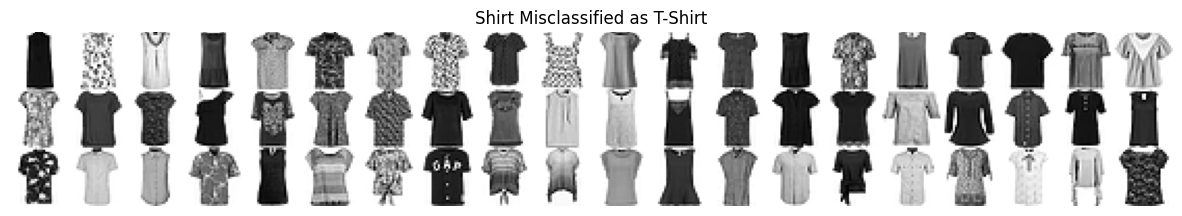

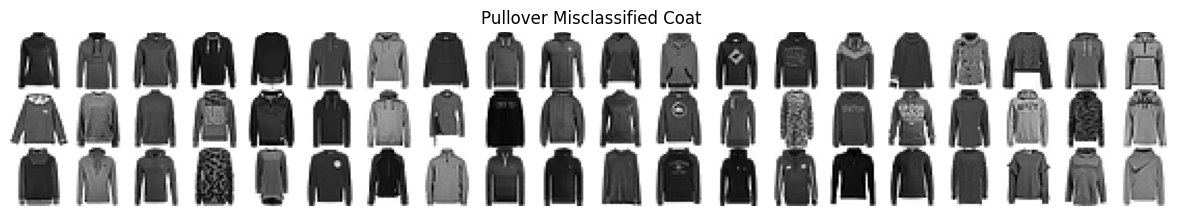

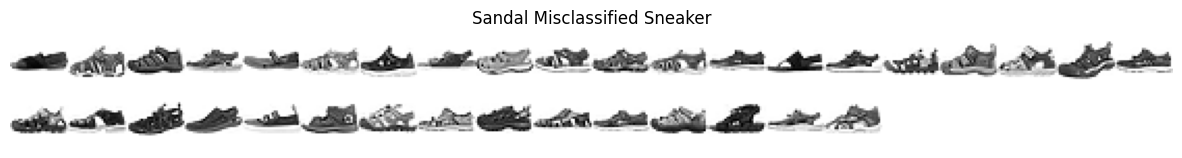

In [33]:
def plot_digits (x_image, image_per_row = 20, title = ''): 
    image_per_row = min (len(x_image), image_per_row)
    row_number = (len(x_image) - 1) // image_per_row + 1 
    empty_number = row_number * image_per_row  - len(x_image) 
    images = [image.reshape(28, 28) for image in x_image] 
    images.append (np.zeros ((28, 28 * empty_number))) 
    image_matrix = []
    for row in range(row_number): 
        image_line = images[row * image_per_row : (row + 1) * image_per_row]
        image_matrix.append (np.concatenate(image_line, axis = 1))
    plot_image = np.concatenate(image_matrix, axis = 0)
    plt.figure (figsize = (15, 7))
    plt.imshow (plot_image, cmap = 'binary') 
    plt.axis ('off')
    plt.title(title)
    plt.show() 

''' 
Random Forest Errors
'''
x_60 = x_test[(y_test == 6) & (y_pred == 0)]
x_24 = x_test[(y_test == 2) & (y_pred == 4)]
x_57 = x_test[(y_test == 5) & (y_pred == 7)]

plot_digits(x_60[:60], title = 'Shirt Misclassified as T-Shirt')
plot_digits(x_24[:60], title = 'Pullover Misclassified Coat')
plot_digits(x_57[:60], title = 'Sandal Misclassified Sneaker')


'''
KNearestNeighbors Errors
'''


plt.show() 